# Chaos, Random Processes, and Predictability

#### 1.1: Objectives

This lecture course will cover some basic phenomenology and concepts behind chaos, random processes and the origins of predictability (or lack thereof) in physical systems. Our aims are:

- to give you some idea of how apparently unpredictable behaviour can arise in relatively simple dynamical systems,

- to demonstrate how geometrical tools can be used to understand the behaviour of such systems even when the underlying equations are impossible to solve explicitly,

- to introduce you to elementary stochastic processes and explain how these can be distinguished from low-order chaotic motion, including the concept of fractal dimension,

- to describe how local predictability can be assessed and exploited in practical forecasting a chaotic system,

- to get comfortable moving ambidextrously between numerical and analytic approaches to modelling, predicting and understanding physical systems.

#### 1.2 Philosophy

Throughout this course, we’ll be emphasizing the importance of non-linearity for real physical systems: almost all of the systems you deal with in the entire Oxford Physics course are linear, which makes analytic solutions tractable. We focus on analytically tractable cases because that's the best way of really understanding the fundamentals -- and because that's how your exams work.

But most of the systems you will deal with after Finals are non-linear: this makes them difficult to model analytically, but often quite straightforward to model numerically. But the analytic tools we will tell you about in this course are essential to understanding your numerical solutions: being able to simulate, and even predict, a system does not mean you have understood it.

The course is examined conventionally, using special cases carefully constructed to be solved with pen, paper and a calculator. You won't need to use Python in the exam, but you won't get nearly as much out of the course without it.

#### 1.3: An example of an interesting non-linear system

The Oxford susceptible-infectious-recovered framework (SIRf) model of the spread of SARS-CoV-2 in the UK:

\begin{eqnarray*}
\dot{y}(t) & = & \beta y (1-z) - \sigma y \\
\dot{z}(t) & = & \beta y (1-z) \\
\Lambda(t) & = & N \rho \theta \; z(t-\psi)\\
\beta & = & R_0 \sigma
\end{eqnarray*}

where
- $y =$ proportion of population who are infectious with SARS-CoV-2 
    - (rate of new infections minus rate at which people stop being infectious)
- $z =$ proportion of initial population no longer susceptible to infection 
    - (because they are either already infected, recovered or dead)
- $\Lambda =$ cumulative deaths
- $t =$ time since disease introduced (days)


##### Key parameters of the SIRf model

- $R_0 =$ "basic reproduction number" (2.25 or 2.75 $\pm$ 0.025)
- $1/\sigma =$ average infectious period (4.5 $\pm$ 1 days)
- $\beta =$ average number of people infected by an infectious individual per day
- $\psi =$ average time between infection and death (17 $\pm$ 2 days)
- $\theta =$ probability of dying with severe disease (0.14 $\pm$ 0.007)
- $\rho =$ proportion of population at risk of severe disease (0.01 or 0.001 $\pm$ 50%)
- $N =$ size of population (67 million)

#### 1.4 Disclaimer:

This is an implementation of the model in Lourenco et al (2020) 
https://www.medrxiv.org/content/10.1101/2020.03.24.20042291v1.full.pdf

The model is legitimate (and we are looking forward to a guest lecture on May 15 from Professor Sunetra Gupta, Professor of Theoretical Epidemiology, Department of Zoology, University of Oxford, and author of "Pandemics: our fears and the facts" to tell us about the dynamics of pandemics), but this implementation was cobbled together one Sunday afternoon deep in the first lockdown, for your interest. 

We know a lot more now than we did then. Notice it didn't occur to me to consider a time-axis longer than 365 days.

We're now going to show you how we can solve this model numerically using Python: there will be lots of examples like this in this course.

In [25]:
# Import some standard Python stuff:
#  you'll need some lines like these at the beginning of most of your Python scripts
# Import basic plotting routines
import matplotlib.pyplot as plt
# Turn on interactive plotting
%matplotlib inline
# Import numerical python routines
import numpy as np
# Import odeint from scientific python routines
from scipy.integrate import odeint

In [30]:
# Define a function for integrating the SIRf model
# Calculates vector [ydot,zdot] given [y,z,beta,sigma] using the model equations
# Indentation is used to indicate lines of code within the function
def SIRf(x, t, beta, sigma):    
    y = x[0]
    z = x[1]
# y = proportion of population infectious with SARS-CoV-2
    dydt = beta*y*(1-z) - sigma*y
# z = proportion of initial population no longer susceptible
    dzdt = beta*y*(1-z)
# function needs to return the vector of time-derivatives
    dxdt = [dydt, dzdt]
    return dxdt

In [31]:
# Some things we can take as fixed
N = 67e6 # initial size of population (67 million)
deltat=0.1 # time-step for the model
# Create a time array [0,0.1,...,364.9] -- Python starts indexing from zero
t = np.arange(0,365,deltat) # time since disease introduced (days)
# Set initial condition: remember that y and z are fractions of population
x0 = [1/N,0]

In [32]:
# Define a function for plotting the SIRf model output
def pltSIRf(t,xt,N,Lambda,R_0):
    print('Total deaths:',int(max(Lambda)))
    plt.figure(figsize=(14,4))
    yscl=['linear','log']
    for n in range(0,2):
        plt.subplot(1,2,n+1)
        plt.plot(t, xt[:,0]*N, label='Infectious')
        plt.plot(t, xt[:,1]*N, label='No longer susceptible')
        plt.plot(t, Lambda, label='Cumulative deaths')
        plt.xlabel('Time since first infection (days)')
        plt.ylabel('Number of people')
        plt.yscale(yscl[n])
        plt.ylim([1,N])
        plt.legend()
        plt.title('SIRf model output for R0='+str(R_0))
# Save your figure (you might want to comment this out if you're just exploring)
#    plt.savefig('figures/SIRf'+str(int(R_0*1000.))+'.png')

Total deaths: 33761


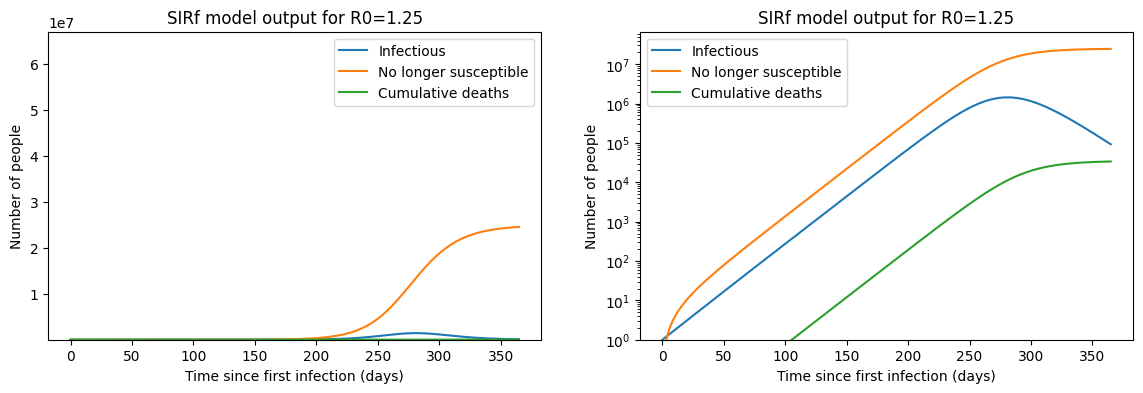

In [33]:
# Define parameters for the SIRf model & integrate
R_0 = 1.25 # basic reproduction number (2.25 or 2.75 pm 0.025)
sigma = 1./4.5 # 1/sigma = average infectious period (4.5 pm 1 days)
beta = R_0*sigma # number of people infected by an infectious individual per day
psi = 17 # average time between infection and death (17 pm 2 days)
theta = 0.14 # probability of dying with severe disease (0.14 pm 0.007)
rho = 0.01 # proportion of population at risk of severe disease (0.01 or 0.001 pm 50%)
xt = odeint(SIRf, x0, t, args=(beta, sigma)) # Integrate the model using scipy.integrate.odeint (see Import module)
Lambda = np.zeros_like(t) # Cumulative deaths are a scalar multiple of the number infected, delayed by psi
Lambda[int(psi/deltat):] = N*rho*theta*xt[0:int((365-psi)/deltat),1]
pltSIRf(t,xt,N,Lambda,R_0)

#### 1.5 Things you could do with this model

First try varying the parameters over the uncertainty ranges given to learn how the time-evolution of the epidemic responds.

Next, more ambitiously, try modifying the function SIRf to make $\beta$ depend on time, so when $t>t_{\rm lockdown}$ you use a smaller value of $R_0$. How many lives can you save?

Or you could try making $\theta$ a non-linear function of $\dot{z}(t-\psi)$, representing the coping capacity of the NHS.

But before you can do any of this, you will need to install Anaconda Python:

#### 1.6 Getting started with Anaconda Python and Jupyter Notebook.

- Go to https://docs.anaconda.com/anaconda/install/ and follow instructions to install Anaconda3. 

    - These scripts have been testing using Python 3. If you are still using Python 2.7, you will need to edit them.
    - If you have limited bandwidth, you may be OK using miniconda, but again, we haven't tested for that.

- If it all goes well, launch Anaconda-Navigator.

- From the Anaconda-Navigator window, launch Jupyter Notebook.

- From the Jupyter Notebook window, go into "Anaconda-Projects" create a folder called "S32-Chaos" 

    - top right "New" button, choose folder, tick checkbox next to it to rename it
    - also create a subdirectory called "figures"

- Save this file (called S32_lect01.ipynb) into that folder using your favourite Windows, Mac or Linux file-save procedure.

- Open this file and use the "Run" button to step through it. You can always scroll back, click on a cell you have already run, and re-run it. 

    - If you break things, a useful button is the curly arrow two right from "Run", which restarts the whole kernel.

- For this lecture, we're only going to use very standard Python. You'll need to install some more packages later on.

#### 1.7 Another biological example

Here is an even simpler example (numerically), but with even more interesting dynamics than the SIRf model.

Budworms breed rapidly, but also exhaust their food supply, so the population in year $n+1$ is given by 
$$ x_{n+1} = r x_n (1 - x_n) $$
where $x_n$ is the population in year $n$, $r$ is the growth rate in the absence of food constraints, and $x_n$ is normalised such that if $x_n = 1$, the budworms eat all their food supply and the population collapses to zero. Apparently this is not a great model of budworm population dynamics (you also need a term to describe birds eating the budworms), but it serves to illustrate how we can get some really interesting behaviour out of a couple of lines of simple Python code.

In [34]:
# define a logistic function which accepts an array of values of x_n and outputs x_{n+1}
def flog(x,r):
    return r*np.multiply(x,(1-x))

# define a logistic map which generates array of n values of x given r & x0
def xlog(n,r,x0):
    x = np.zeros(n)
    x[0]=x0
    for n in range(0,nyr-1):
        x[n+1]=r*x[n]*(1-x[n])
    return x

# And some variables that don't change
nyr =2**9
t = np.arange(nyr)
x1= np.arange(nyr)/(nyr-1)
x0= 0.2

In [7]:
# Plot the output of the logistic map, both 1st 32 years and full 512 years
def pltxlog(t,x,r):
    plt.figure(figsize=(15,12))
    plt.subplot(2,2,1)
    plt.plot(t, x)
    plt.xlabel('Years')
    plt.ylabel('Normalised population')
    nyr=np.size(t)
    npl=100
    plt.xlim([0,npl])
    plt.ylim([0,1])
    plt.text(npl*0.06,0.06,'Logistic map with r='+str(r))
    plt.subplot(2,2,2)
# calculate the power spectrum of 2nd half of the series after initial transients have died away
    p_x = np.square(np.abs(np.fft.rfft(x[int(nyr/2):]-np.mean(x[int(nyr/2):]))))
    frq = np.arange(1, len(p_x)+1)/(2.*len(p_x))
    plt.plot(frq[1:], p_x[1:])
    plt.xlabel('Frequency (years$^{-1}$)')
    plt.ylabel('Power spectral density')
    plt.yscale('log')
    plt.xlim([0,0.51])
    # Create an array of 6-monthly population [x[0],x[0],x[1],x[1],...]
    x2 = np.repeat(x[0:nyr-1],2)
    for n in range(0,2):
        plt.subplot(2,2,n+3)
        plt.plot(x1, x1)
        plt.plot(x1, flog(x1,r), label='$f(x)$')
        if n == 0:
            plt.plot(x2[0:npl-1],x2[1:npl], label='Initial years')
            plt.plot(x2[nyr-npl:nyr-1],x2[nyr-npl+1:nyr], label='Final years')
        else:
            plt.plot(x1, flog(flog(x1,r),r), label='$f^2(x)$')
            plt.plot(x1, flog(flog(flog(x1,r),r),r), label='$f^3(x)$')
            plt.plot(x1, flog(flog(flog(flog(x1,r),r),r),r), label='$f^4(x)$')
        plt.xlabel('$x_n$')
        plt.ylabel('$x_{n+1}$')
        plt.xlim([0,1])
        plt.ylim([0,1])
        plt.legend()
#    plt.savefig('figures/Logist_out'+str(int(r*1000.))+'.png')

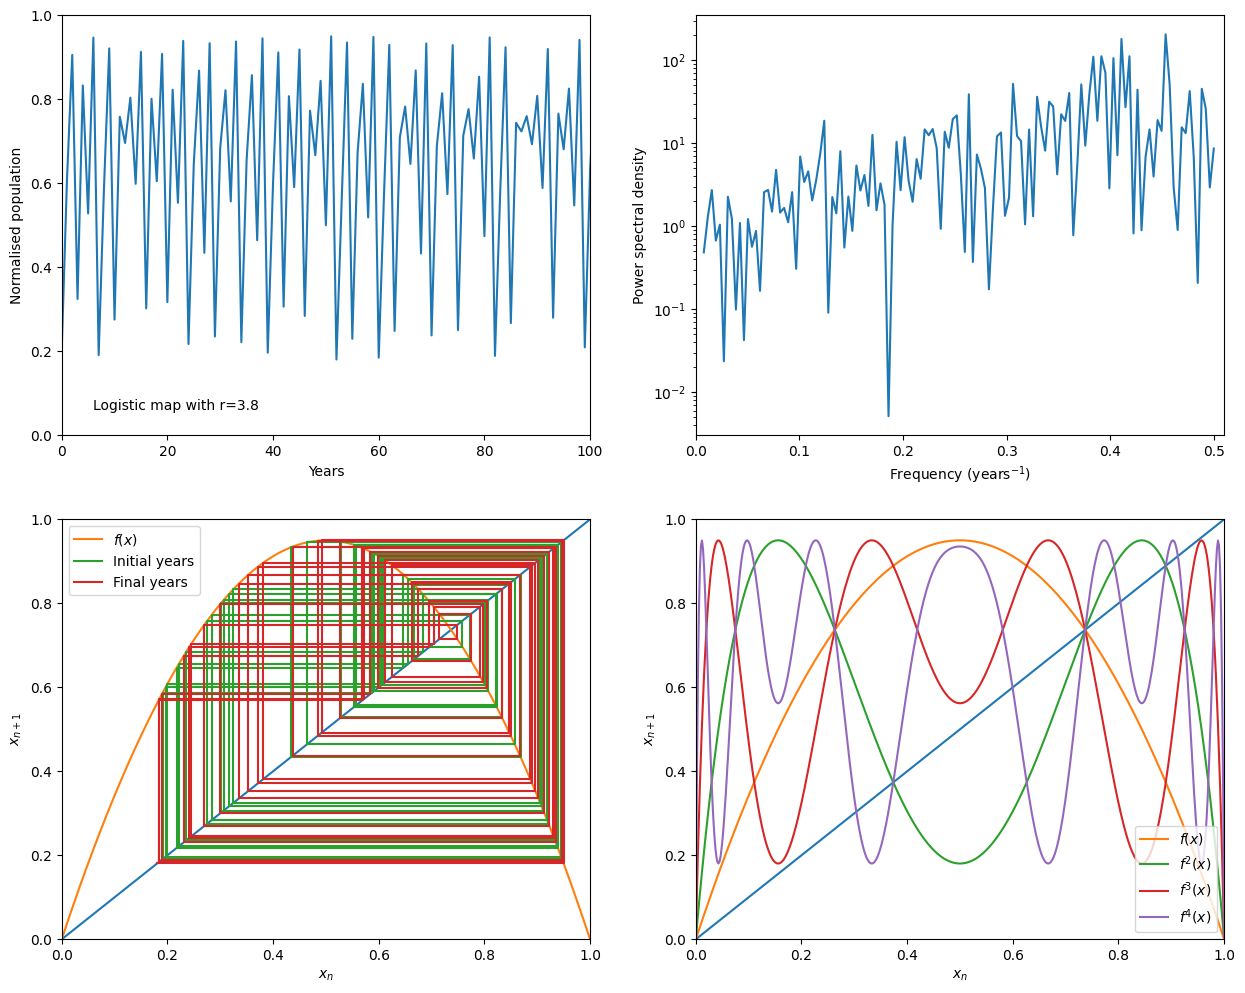

In [8]:
r = 3.8 #try: 0.99, 2.99, 3.5, 1+np.sqrt(8), 3.8
x = xlog(nyr,r,x0)
pltxlog(t,x,r)

#### 1.8 Analysis of the logistic map

Hannah will explain that you cannot generate chaotic variability from a 1-D differential equation, so how can it emerge from a discrete map?

The answer is that budworm population growth in a given season depends on how much they ate the preceding season, introducing a memory that allows it to behave in ways a continuous 1-D ODE cannot.

So it helps to think in terms of 6-month intervals, with the population $x_n$in the second six months of year $n$ carried over to the first six months of year $n+1$: no change in population over the "winter", but also no replenishment of food supply.

It also helps to define a logistic function
$$ f_{\rm log}(x) = r x (1-x)$$
so the population after 2, 3 etc. years is:
$$ f_{\rm log}^2(x) = f_{\rm log}(f_{\rm log}(x)) \; ; \; f_{\rm log}^3(x) =  f_{\rm log}(f_{\rm log}(f_{\rm log}(x)))$$

#### 1.9 Things to do with the logistic map

Try varying $r$ (note it is defined in two places: poor coding, but how I could get the slides to work). 

Interesting values are:
- $r=1$ (first appearance of a non-zero stable population, or "fixed point")
- $r=3$ (first appearance of a population oscillating between two values, or "2-cycle")
- $r=1+\sqrt{6}$ (2-cycle goes unstable, and becomes a stable 4-cycle)
- $r=3.54409$... (4-cycle goes unstable, and becomes a stable 8-cycle)
- $r=3.569946$... (period becomes infinite -- non-repeating)
- $r=1+\sqrt{8}$ (stable 3-cycle appears out of chaos)

In each case, try varying $r$ from just below to just above the critical number to see how the behaviour changes. A qualitative change in system behaviour through an infinitesimal change to a parameters is called a "bifurcation". 

Philosophical question: you can predict numerically exactly (almost, within machine precision, anyway) how the logistic map behaves for various settings of $x_0$ and the $r$ parameter, but have you "understood" it? 

#### 1.10 Before you get too excited...

The logistic map was revolutionary for mathematical biologists, because it showed how you didn't need random shocks from external drivers to get highly unpredictable, random-looking behaviour. 

But this doesn't mean that random shocks can't give unpredictable, random-looking behaviour: in fact, most often when you see a series that looks random, it just is just that.

So we will devote a couple of lectures to simple linear stochastic processes, and how you can distinguish these from low-dimensional chaos.

#### 1.11 Lecture outline

Lectures will given live in the Lindemann Theatre. They will be recorded as usual, but we very strongly recommend you to attend in person. We will run a Python trouble-shooting session on Thursday, April 25, 9-10am. Please attend this even if you are already fluent in Python, because we will be relying on you to help your peers get started. 


1. Introduction, overview of this Short Option, and a couple of examples -- this lecture.
    - Myles, Wednesday, April 24, 11-12am
    
   
2. A geometric interpretation of one-dimensional ODEs: flows on a line + getting going with Python
    - Hannah, Thursday, April 25, 9-10am
    
    
3. Two-dimensional flows: phase portraits, fixed points and the Jacobian.
    - Hannah, Friday, April 26, 9-10am
    

4. Two-dimensional flows continued: limit cycles, control parameters and bifurcations.
    - Hannah, Wednesday, May 1, 11-12 am

#### Lecture outline, continued

5. Three-dimensional flows: the Lorenz equations, chaos and strange attractors.
    - Hannah, Thursday, May 2, 9-10am


6. Catch-up and summary of part 1. Introduction to problem sets.
    - Hannah, Friday, May 3, 9-10am


7. Introduction to stochastic processes: linear models, autocovariance and the power spectrum.
    - Myles, Wednesday, May 8, 11-12am
    
    
8. Distinguishing low-dimensional chaos from a linear stochastic processes: fractal dimension.
    - Myles, Thursday, May 9, 9-10am

#### Lecture outline, continued

9. Local predictability of chaotic systems: understanding the Jacobian
    - Myles, Friday, May 10, 9-10am


10. Non-linear modelling in epidemiology, including the example of SARS-Cov-2
    - Guest lecture: Professor Sunetra Gupta, Department of Zoology, Wednesday, May 15, 11-12am


11. Chaos and predictability from weather forecasting to quantum mechanics
    - Guest lecture: Professor Tim Palmer, Department of Physics, Thursday, May 16, 9-10am


12. Global dynamics of error growth, Lyapunov exponents and attractor dimensions
    - Myles, Friday, May 17, 9-10am
    
    

